In [68]:
from typing import TYPE_CHECKING
from importlib.resources import files
from neuromodes.io import fetch_example_surf, fetch_example_map
from nsbutils.plotting_pyvista import plot_surf
from neuromodes import EigenSolver
import numpy as np
import matplotlib.pyplot as plt
from lapy import Solver
from lapy.diffgeo import compute_geodesic_f
from scipy.sparse.linalg import splu
import potpourri3d as pp3d
from scipy.spatial import KDTree
from scipy.sparse import eye
from neuromodes.stats import parcellate, varw, zscorew
from time import time

if TYPE_CHECKING:
    from numpy.typing import NDArray
    from scipy.sparse import spmatrix

In [ ]:
def make_cvt_parcellation(
    geometry,
    n_parcels,
    max_iterations,
    seed = 0
):
    m = 1.0
    n_verts = geometry.v.shape[0]
    seeds = np.random.default_rng(seed).choice(n_verts, size=n_parcels, replace=False)
    # TODO: farthest point sampling to get faster convergence?
    
    # Precompute LU for geodesic computation
    solver_lapy = Solver(geometry, lump=True)
    hmat = solver_lapy.mass + m * geometry.avg_edge_length()**2 * solver_lapy.stiffness
    lu = splu(hmat)

    # Precompute change of basis matrices (u, v) -> (x, y, z)
    solver_pp3d = pp3d.MeshVectorHeatSolver(geometry.v, geometry.t)
    basisX, basisY, _ = solver_pp3d.get_tangent_frames()

    # initialise arrays
    sources = np.zeros((n_verts, n_parcels), dtype=np.float64)
    all_parcellations = np.empty((n_verts, max_iterations), dtype=np.int32)
    log_maps = np.empty((n_verts, 2, n_parcels), dtype=np.float64)  # TODO: can save memory by only keeping current log map
    log_map_combined = np.empty((n_verts, 2), dtype=np.float64)
    seeds_updated = np.empty_like(seeds)
    seeds_unchanged = np.zeros(n_parcels, dtype=bool)

    # Voronoi iteration
    logging_time = 0.0
    for i in range(max_iterations):
        
        # Heat diffusion from current seeds
        sources[:, :] = 0.0
        for k, vert in enumerate(seeds):
            sources[vert, k] = 1.0
        heat = lu.solve(sources)  # shape (n_verts, n_parcels)
        dists = compute_geodesic_f(geometry, heat)  # TODO: unwrap, as mass/stiffness is unchanged across iterations

        # Build parcellation as nearest seed
        parcellation = np.argmin(dists, axis=1)
        all_parcellations[:, i] = parcellation

        # Calculate log map for each seed, keep values for each parcel, stitch into combined map
        t0 = time()
        for k in range(n_parcels):
            parcel_verts = np.where(parcellation == k)[0]
            if not seeds_unchanged[k]:  # only recompute log map if seed has moved
                log_maps[:, :, k] = solver_pp3d.compute_log_map(seeds[k])
            log_map_combined[parcel_verts, :] = log_maps[parcel_verts, :, k]
        t1 = time()
        logging_time += (t1 - t0)

        # parcellate the combined log map to get update vectors (TODO: check if non-eye mass is needed)
        update_vectors = parcellate(log_map_combined, parcellation, solver_lapy.mass)  # shape (n_parcels, 2)
        update_vectors_3d = (update_vectors[:, [0]] * basisX[seeds, :]  # TODO: can make a single mult by stacking
                             + update_vectors[:, [1]] * basisY[seeds, :])  # shape (n_parcels, 3)
        seeds_updated_loc = geometry.v[seeds, :] + update_vectors_3d
        
        for k in range(n_parcels):
            parcel_verts = np.where(parcellation == k)[0]
            tree = KDTree(geometry.v[parcel_verts, :])
            nearest_local = tree.query(seeds_updated_loc[k])[1] 
            seeds_updated[k] = parcel_verts[nearest_local]

        seeds_unchanged = (seeds_updated == seeds)
        print(f"Iteration {i+1}: Moved {np.sum(~seeds_unchanged)} seeds")
        
        # Early stopping if converged
        if np.all(seeds_unchanged):
            all_parcellations = all_parcellations[:, :i+1]
            print("Converged early!")
            break
        seeds = seeds_updated.copy()

    print(f"Logging time: {logging_time}")
    return all_parcellations

In [30]:
# config
surf_path = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_sphere.surf.gii'
solver = EigenSolver(surf_path)
n_parcels = 10
max_iterations = 20
seed = 0

In [31]:
# test non-eye mass
solver.geometry.v[:, 2] *= 2
parcellation = make_cvt_parcellation(solver.geometry, n_parcels, max_iterations, seed)

Iteration 1: Moved 10 seeds
Iteration 2: Moved 10 seeds
Iteration 3: Moved 9 seeds
Iteration 4: Moved 9 seeds
Iteration 5: Moved 9 seeds
Iteration 6: Moved 9 seeds
Iteration 7: Moved 8 seeds
Iteration 8: Moved 8 seeds
Iteration 9: Moved 8 seeds
Iteration 10: Moved 8 seeds
Iteration 11: Moved 8 seeds
Iteration 12: Moved 8 seeds
Iteration 13: Moved 10 seeds
Iteration 14: Moved 8 seeds
Iteration 15: Moved 10 seeds
Iteration 16: Moved 9 seeds
Iteration 17: Moved 4 seeds
Iteration 18: Moved 5 seeds
Iteration 19: Moved 5 seeds
Iteration 20: Moved 5 seeds
Logging time: 22.885525465011597


In [38]:
# boxplot of parcel areas over iterations
idx = np.array([1, 2, 5, parcellation.shape[1]])
idx -= 1
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

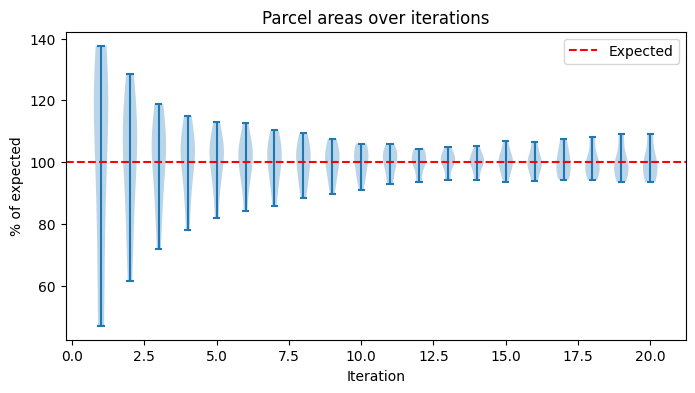

In [47]:
expected = solver.geometry.area() / n_parcels
plt.violinplot(parc_areas / expected * 100)
plt.axhline(100, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('% of expected')
plt.title('Parcel areas over iterations')
plt.legend()
# plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

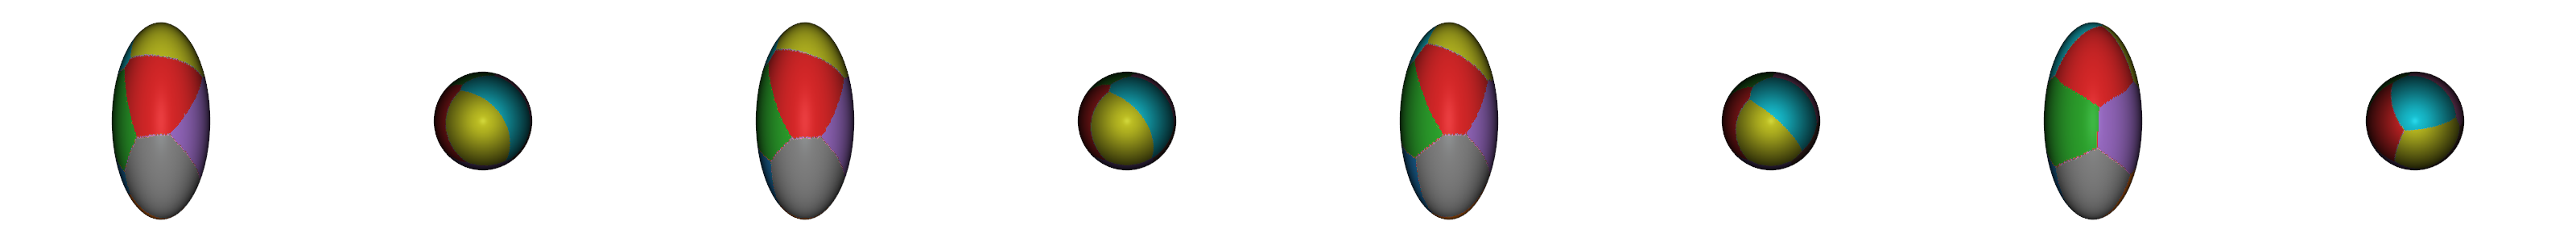

In [41]:
fig = plot_surf({'lh': solver.geometry}, {'lh': parcellation[:, idx]}, cmap='tab10', views=['lateral', 'dorsal'], zoom=1)#, rois={'lh': parcellation[:, 0]}, roi_outlines=True)
fig.show(jupyter_backend='static')

### Try another seed

In [4]:
seed = 1
parcellation = make_cvt_parcellation(solver.geometry, n_parcels, max_iterations, seed)

Iteration 1: Moved 10 seeds
Iteration 2: Moved 10 seeds
Iteration 3: Moved 9 seeds
Iteration 4: Moved 9 seeds
Iteration 5: Moved 8 seeds
Iteration 6: Moved 7 seeds
Iteration 7: Moved 5 seeds
Iteration 8: Moved 5 seeds
Iteration 9: Moved 2 seeds
Iteration 10: Moved 3 seeds
Iteration 11: Moved 0 seeds
Converged early!
Logging time: 19.30398964881897


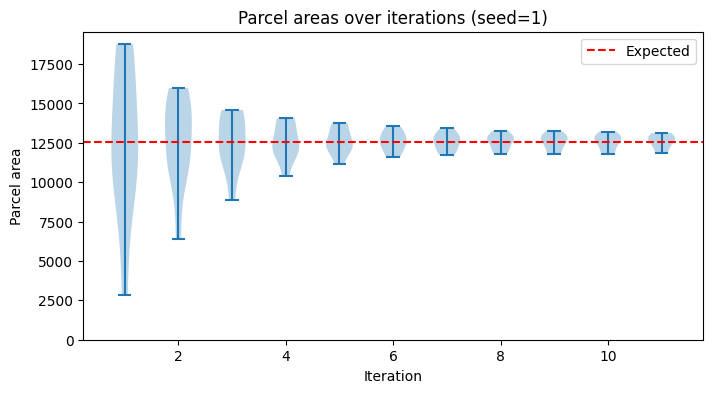

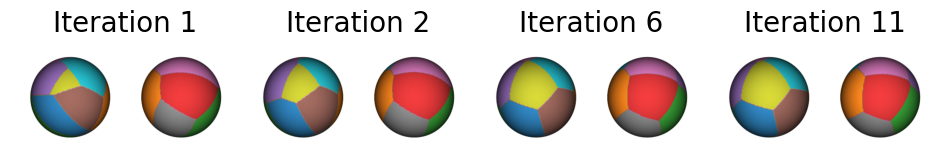

In [5]:
# boxplot of parcel areas over iterations
idx = np.array([1, 2, 6, parcellation.shape[1]])
idx -= 1
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

plt.violinplot(parc_areas)
plt.axhline(solver.geometry.area() / n_parcels, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('Parcel area')
plt.title('Parcel areas over iterations (seed=1)')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

plot_surf(surf_path, parcellation[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

In [6]:
# Try another seed
seed = 2
parcellation = make_cvt_parcellation(solver.geometry, n_parcels, max_iterations, seed)

Iteration 1: Moved 10 seeds
Iteration 2: Moved 10 seeds
Iteration 3: Moved 10 seeds
Iteration 4: Moved 8 seeds
Iteration 5: Moved 9 seeds
Iteration 6: Moved 9 seeds
Iteration 7: Moved 5 seeds
Iteration 8: Moved 6 seeds
Iteration 9: Moved 3 seeds
Iteration 10: Moved 4 seeds
Iteration 11: Moved 1 seeds
Iteration 12: Moved 1 seeds
Iteration 13: Moved 0 seeds
Converged early!
Logging time: 22.25517225265503


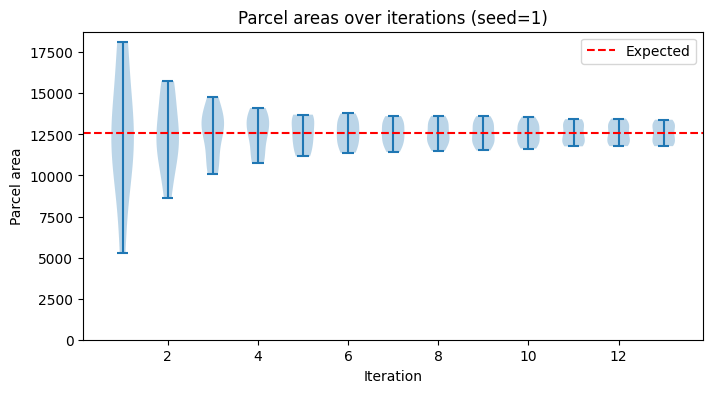

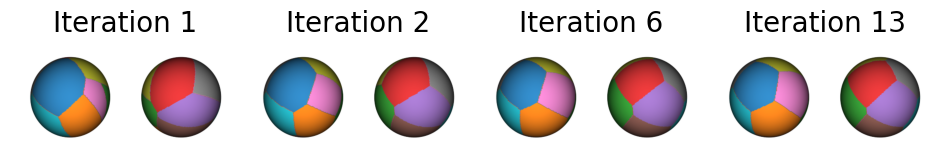

In [7]:
# boxplot of parcel areas over iterations
idx = np.array([1, 2, 6, parcellation.shape[1]])
idx -= 1
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

plt.violinplot(parc_areas)
plt.axhline(solver.geometry.area() / n_parcels, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('Parcel area')
plt.title('Parcel areas over iterations (seed=1)')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

plot_surf(surf_path, parcellation[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

### Cortex + medial wall

In [48]:
# config
surf_path = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
solver = EigenSolver(surf_path)

In [49]:
seed = 0
parcellation = make_cvt_parcellation(solver.geometry, n_parcels, 100, seed)

Iteration 1: Moved 10 seeds
Iteration 2: Moved 10 seeds
Iteration 3: Moved 10 seeds
Iteration 4: Moved 10 seeds
Iteration 5: Moved 10 seeds
Iteration 6: Moved 9 seeds
Iteration 7: Moved 7 seeds
Iteration 8: Moved 4 seeds
Iteration 9: Moved 5 seeds
Iteration 10: Moved 7 seeds
Iteration 11: Moved 5 seeds
Iteration 12: Moved 6 seeds
Iteration 13: Moved 4 seeds
Iteration 14: Moved 5 seeds
Iteration 15: Moved 6 seeds
Iteration 16: Moved 6 seeds
Iteration 17: Moved 8 seeds
Iteration 18: Moved 7 seeds
Iteration 19: Moved 7 seeds
Iteration 20: Moved 4 seeds
Iteration 21: Moved 9 seeds
Iteration 22: Moved 6 seeds
Iteration 23: Moved 7 seeds
Iteration 24: Moved 7 seeds
Iteration 25: Moved 8 seeds
Iteration 26: Moved 8 seeds
Iteration 27: Moved 7 seeds
Iteration 28: Moved 6 seeds
Iteration 29: Moved 8 seeds
Iteration 30: Moved 6 seeds
Iteration 31: Moved 7 seeds
Iteration 32: Moved 7 seeds
Iteration 33: Moved 7 seeds
Iteration 34: Moved 8 seeds
Iteration 35: Moved 6 seeds
Iteration 36: Moved 6 se

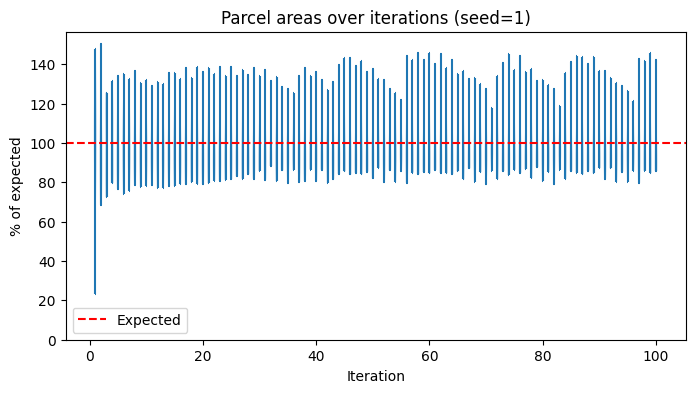

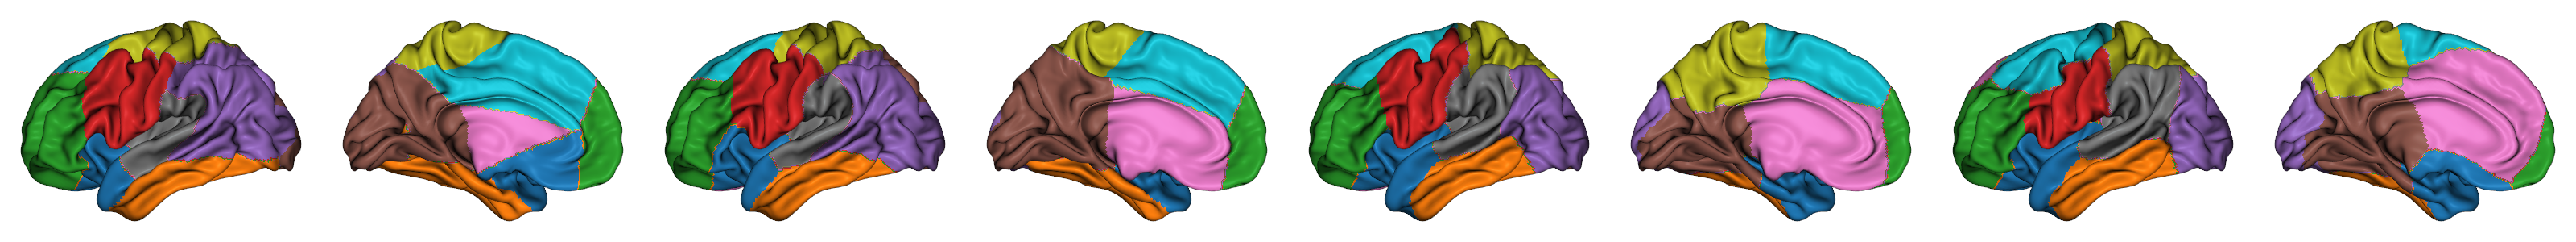

In [54]:
# boxplot of parcel areas over iterations
idx = np.array([1, 2, 5, parcellation.shape[1]])
idx -= 1
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

expected = solver.geometry.area() / n_parcels
plt.violinplot(parc_areas / expected * 100)
plt.axhline(100, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('% of expected')
plt.title('Parcel areas over iterations (seed=1)')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

fig = plot_surf({'lh': solver.geometry}, {'lh': parcellation[:, idx]}, cmap='tab10', views=['lateral', 'medial'], zoom=1.5)
fig.show(jupyter_backend='static')

In [12]:
# Try another seed
seed = 1
parcellation = make_cvt_parcellation(solver.geometry, n_parcels, 50, seed)

Iteration 1: Moved 10 seeds
Iteration 2: Moved 10 seeds
Iteration 3: Moved 10 seeds
Iteration 4: Moved 9 seeds
Iteration 5: Moved 10 seeds
Iteration 6: Moved 9 seeds
Iteration 7: Moved 10 seeds
Iteration 8: Moved 10 seeds
Iteration 9: Moved 8 seeds
Iteration 10: Moved 9 seeds
Iteration 11: Moved 9 seeds
Iteration 12: Moved 9 seeds
Iteration 13: Moved 6 seeds
Iteration 14: Moved 7 seeds
Iteration 15: Moved 4 seeds
Iteration 16: Moved 4 seeds
Iteration 17: Moved 7 seeds
Iteration 18: Moved 8 seeds
Iteration 19: Moved 8 seeds
Iteration 20: Moved 10 seeds
Iteration 21: Moved 9 seeds
Iteration 22: Moved 10 seeds
Iteration 23: Moved 7 seeds
Iteration 24: Moved 8 seeds
Iteration 25: Moved 8 seeds
Iteration 26: Moved 9 seeds
Iteration 27: Moved 6 seeds
Iteration 28: Moved 7 seeds
Iteration 29: Moved 8 seeds
Iteration 30: Moved 9 seeds
Iteration 31: Moved 8 seeds
Iteration 32: Moved 9 seeds
Iteration 33: Moved 9 seeds
Iteration 34: Moved 9 seeds
Iteration 35: Moved 9 seeds
Iteration 36: Moved 9

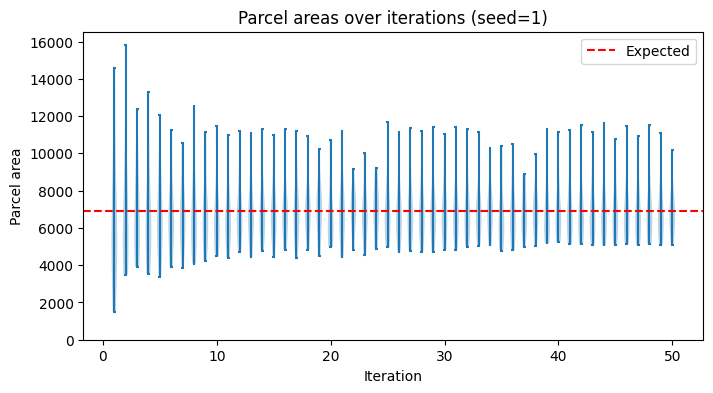

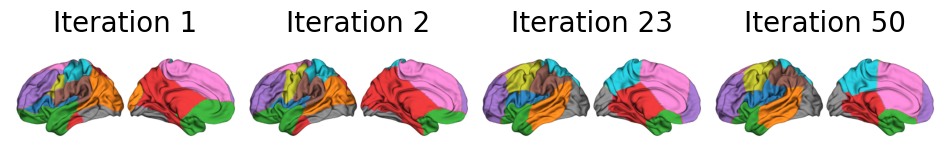

In [13]:
# boxplot of parcel areas over iterations
parcellation = parcellation
idx = np.array([1, 2, 23, parcellation.shape[1]])
idx -= 1
areas = solver.mass.sum(axis=1).A1
parc_areas = np.zeros((n_parcels, idx[-1]+1))
for i in range(n_parcels):
    for j in range(idx[-1]+1):
        mask = parcellation == i
        parc_areas[i, j] = areas[mask[:, j]].sum()

plt.violinplot(parc_areas)
plt.axhline(solver.geometry.area() / n_parcels, color='red', linestyle='--', label='Expected')
plt.xlabel('Iteration')
plt.ylabel('Parcel area')
plt.title('Parcel areas over iterations (seed=1)')
plt.legend()
plt.ylim(bottom=0)
plt.gcf().set_size_inches(8, 4)
plt.show()

plot_surf(surf_path, parcellation[:, idx], labels=[f'Iteration {i+1}' for i in idx], cmap='tab10')

In [14]:
seed = 0
parcellation100 = make_cvt_parcellation(solver.geometry, 100, 10, seed)

Iteration 1: Moved 97 seeds
Iteration 2: Moved 89 seeds
Iteration 3: Moved 79 seeds
Iteration 4: Moved 72 seeds
Iteration 5: Moved 69 seeds
Iteration 6: Moved 69 seeds
Iteration 7: Moved 61 seeds
Iteration 8: Moved 58 seeds
Iteration 9: Moved 51 seeds
Iteration 10: Moved 43 seeds
Logging time: 101.96821761131287


In [57]:
# Try no medial wall
surf, medmask = fetch_example_surf()
solver = EigenSolver(surf, medmask)
parcellation = make_cvt_parcellation(solver.geometry, 20, 50, seed)

Iteration 1: Moved 20 seeds
Iteration 2: Moved 20 seeds
Iteration 3: Moved 19 seeds
Iteration 4: Moved 19 seeds
Iteration 5: Moved 19 seeds
Iteration 6: Moved 17 seeds
Iteration 7: Moved 19 seeds
Iteration 8: Moved 15 seeds
Iteration 9: Moved 14 seeds
Iteration 10: Moved 12 seeds
Iteration 11: Moved 12 seeds
Iteration 12: Moved 12 seeds
Iteration 13: Moved 9 seeds
Iteration 14: Moved 10 seeds
Iteration 15: Moved 6 seeds
Iteration 16: Moved 6 seeds
Iteration 17: Moved 7 seeds
Iteration 18: Moved 4 seeds
Iteration 19: Moved 5 seeds
Iteration 20: Moved 5 seeds
Iteration 21: Moved 2 seeds
Iteration 22: Moved 3 seeds
Iteration 23: Moved 3 seeds
Iteration 24: Moved 3 seeds
Iteration 25: Moved 3 seeds
Iteration 26: Moved 3 seeds
Iteration 27: Moved 3 seeds
Iteration 28: Moved 3 seeds
Iteration 29: Moved 3 seeds
Iteration 30: Moved 3 seeds
Iteration 31: Moved 3 seeds
Iteration 32: Moved 3 seeds
Iteration 33: Moved 3 seeds
Iteration 34: Moved 3 seeds
Iteration 35: Moved 3 seeds
Iteration 36: Mo

In [61]:
def calc_homogeneity(
    data: NDArray[np.floating],
    parcellation: NDArray[np.integer],
    mass: spmatrix
) -> NDArray[np.floating]:
    if data_is_vec := data.ndim == 1:
        data = data[:, None]
    n_verts, n_maps = data.shape

    # Get areas
    vert_areas = mass.sum(axis=1).A1
    parc_areas = parcellate(np.ones(n_verts), parcellation, mass)
    n_parcels = parc_areas.shape[0]

    # Get variance within each parcel (TODO: vectorise via sparse matmul, add method='var' to parcellate)
    var_parc = np.empty((n_parcels, n_maps))
    for i in range(n_parcels):
        parcel_mask = (parcellation == i)
        var_parc[i, :] = varw(data[parcel_mask, :], vert_areas[parcel_mask])

    # Calculate homogeneity as weighted average of parcel means
    homogeneity = np.average(var_parc, weights=parc_areas, axis=0)
    return homogeneity[0] if data_is_vec else homogeneity

In [69]:
map_names = ['thickness', 'fcgradient1', 'ndi', 'odi', 'myelinmap']
maps = np.stack([fetch_example_map(name)[medmask] for name in map_names], axis=1)
maps_z = zscorew(maps, solver.mass)
homogeneity = calc_homogeneity(maps_z, parcellation[:, -1], solver.mass)

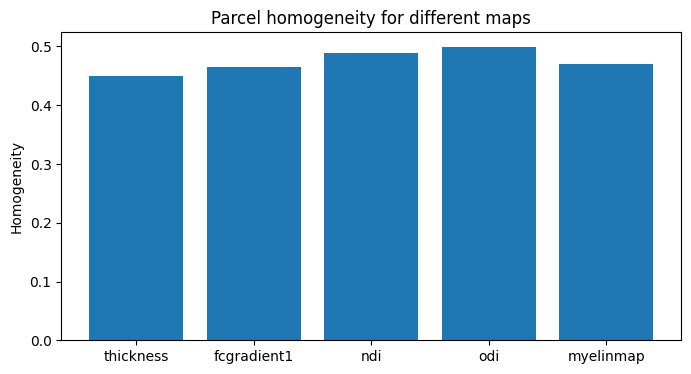

In [70]:
plt.bar(map_names, homogeneity)
plt.ylabel('Homogeneity')
plt.title('Parcel homogeneity for different maps')
plt.gcf().set_size_inches(8, 4)
plt.show()